In [41]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.ndimage as ndi
from sklearn.cluster import KMeans


In [42]:
root = os.getcwd()
print(root)
img_gray = cv.imread("./../images/Trifoil_Ref24.tif", cv.IMREAD_GRAYSCALE)

c:\Users\PC\Desktop\UN\OpticsWork\codefiles\thesisreproduction\22-11-AlgorithmTest\codefiles


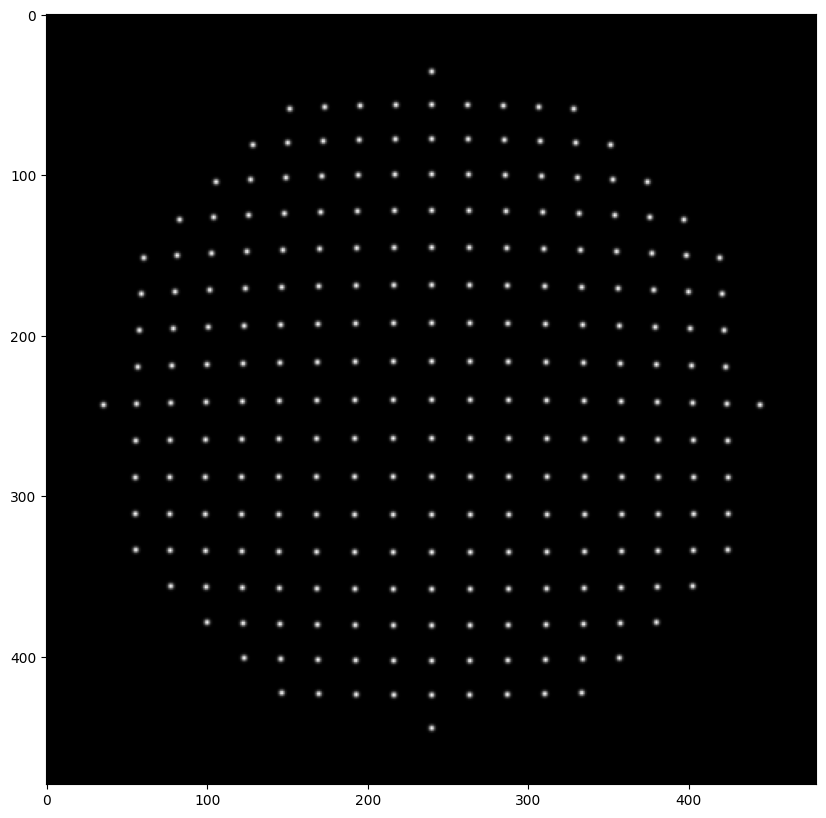

In [43]:
plt.figure(figsize=(10,10))
plt.imshow(img_gray, cmap="gray")


In [44]:
# --- 1. Parameters ---
threshold_value = 30 # Adjusted based on your logs
expected_spots = 253
number_of_columns = 19
output_filename = './../data/22-11-TestSurTrifoil.txt'

# --- 2. Load the Image ---
root = os.getcwd()
img_path = os.path.join(root, "./../images/Trifoil_Ref24.tif")
img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    print(f"Error: Could not load image '{img_path}'.")
else:
    print(f"Successfully loaded image with shape {img_gray.shape}")

    # --- 3. Isolate the Spots ---
    ret, binary_mask = cv.threshold(img_gray, threshold_value, 255, cv.THRESH_BINARY)
    print(f"Created binary mask with threshold={threshold_value}.")

    # --- 4. Find Labels and Stats ---
    num_labels, labels_matrix, stats, centroids = cv.connectedComponentsWithStats(binary_mask)
    
    all_blob_sizes = stats[1:, cv.CC_STAT_AREA]
    all_blob_sizes_sorted = sorted(all_blob_sizes, reverse=True)
    
    print(f"Found {len(all_blob_sizes_sorted)} total blobs.")

    # --- 5 & 6. Logic to Find Valid Indices ---
    valid_indices = []
    
    if len(all_blob_sizes_sorted) < expected_spots:
        print(f"*** ERROR: Found fewer than {expected_spots} spots. Lower the threshold. ***")
        
    elif len(all_blob_sizes_sorted) == expected_spots:
        # CASE 2: Exact match (No noise)
        print(f"--- Exact match ({expected_spots} spots). Keeping all. ---")
        valid_indices = list(range(1, num_labels)) # Keep all labels
        
    else:
        # CASE 3: More spots than expected (Filter noise)
        size_of_last_spot = all_blob_sizes_sorted[expected_spots - 1]
        size_of_first_noise = all_blob_sizes_sorted[expected_spots]
        min_spot_size = (size_of_last_spot + size_of_first_noise) / 2
        
        print(f"--- Filtering noise. Cutoff size: {int(min_spot_size)} ---")
        
        for label_id in range(1, num_labels):
            if stats[label_id, cv.CC_STAT_AREA] > min_spot_size:
                valid_indices.append(label_id)

    # --- Proceed only if we have valid spots ---
    if len(valid_indices) > 0:
        print(f"Processing {len(valid_indices)} valid spots...")

        # --- 7. Calculate Centroids ---
        precise_centroids_yx = ndi.center_of_mass(img_gray, labels=labels_matrix, index=valid_indices)
        
        # --- 8. Organize with Clustering (The missing part) ---
        centroids_xy = [(coord[1], coord[0]) for coord in precise_centroids_yx]
        x_coords = np.array([c[0] for c in centroids_xy]).reshape(-1, 1)

        if len(x_coords) < number_of_columns:
            print(f"Error: Not enough spots to form {number_of_columns} columns.")
        else:
            kmeans = KMeans(n_clusters=number_of_columns, n_init=10, random_state=0)
            column_labels = kmeans.fit_predict(x_coords)
            
            cluster_centers = kmeans.cluster_centers_.flatten()
            cluster_sort_order = np.argsort(cluster_centers)
            cluster_map = {original: sorted_id for sorted_id, original in enumerate(cluster_sort_order)}

            sortable_list = []
            for i in range(len(centroids_xy)):
                spot_xy = centroids_xy[i]
                original_id = column_labels[i]
                sorted_id = cluster_map[original_id]
                # Sort by Column ID first, then Y-coordinate
                sortable_list.append(((sorted_id, spot_xy[1]), spot_xy))

            sorted_list = sorted(sortable_list, key=lambda x: x[0])
            sorted_centroids = [item[1] for item in sorted_list]

            # --- 9. Save to File (The other missing part) ---
            with open(output_filename, 'w') as f:
                for i, (x, y) in enumerate(sorted_centroids):
                    label = i + 1
                    f.write(f"{label} {x:.8f} {y:.8f}\n")

            print(f"Successfully saved {len(sorted_centroids)} sorted spots to '{output_filename}'.")
    else:
        print("No valid spots found to process.")

Successfully loaded image with shape (480, 480)
Created binary mask with threshold=30.
Found 253 total blobs.
--- Exact match (253 spots). Keeping all. ---
Processing 253 valid spots...
Successfully saved 253 sorted spots to './../data/22-11-TestSurTrifoil.txt'.
